# Why Multiply Rise x Run?

Why can't we just square both and divide? This notebook shows you exactly what goes wrong.

## Setup: 6 buildings that clearly go upward

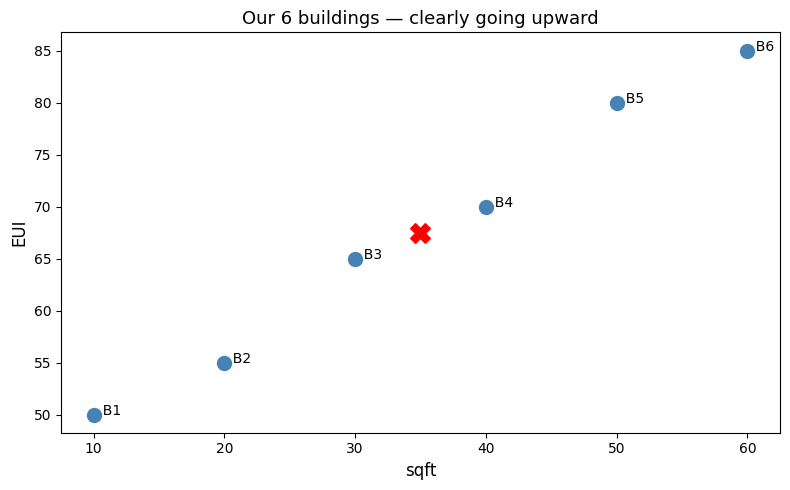

These points go up and to the right. The slope should be POSITIVE.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 6 buildings — clear upward trend
sqft = np.array([10, 20, 30, 40, 50, 60], dtype=float)
eui  = np.array([50, 55, 65, 70, 80, 85], dtype=float)

avg_sqft = sqft.mean()
avg_eui = eui.mean()

runs  = sqft - avg_sqft
rises = eui - avg_eui

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sqft, eui, color='steelblue', s=100, zorder=5)
ax.scatter(avg_sqft, avg_eui, color='red', s=200, marker='X', zorder=5)
for i in range(len(sqft)):
    ax.annotate(f'  B{i+1}', xy=(sqft[i], eui[i]), fontsize=10)
ax.set_xlabel('sqft', fontsize=12)
ax.set_ylabel('EUI', fontsize=12)
ax.set_title('Our 6 buildings — clearly going upward', fontsize=13)
plt.tight_layout()
plt.show()

print('These points go up and to the right. The slope should be POSITIVE.')

## Both methods give the same answer here
When ALL points agree on the direction, both methods work. Let's verify.

In [2]:
# Our method: (run x rise) / (run squared)
our_slope = (runs * rises).sum() / (runs ** 2).sum()

# Your idea: (rise squared) / (run squared)
# But we need to take square root to get back to normal units
your_slope = np.sqrt((rises ** 2).sum() / (runs ** 2).sum())

print('When all points agree on direction:')
print(f'  Our method (run x rise / run²):     {our_slope:.4f}')
print(f'  Your idea  (sqrt(rise² / run²)):     {your_slope:.4f}')
print()
print('Close! Both give a positive slope. So far so good.')
print()
print('But what happens when a point DISAGREES with the trend?')

When all points agree on direction:
  Our method (run x rise / run²):     0.7286
  Your idea  (sqrt(rise² / run²)):     0.7319

Close! Both give a positive slope. So far so good.

But what happens when a point DISAGREES with the trend?


## Now let's break it: one point that goes AGAINST the trend
We'll change Building 4 so it has HIGH sqft but LOW EUI — it disagrees with the upward pattern.

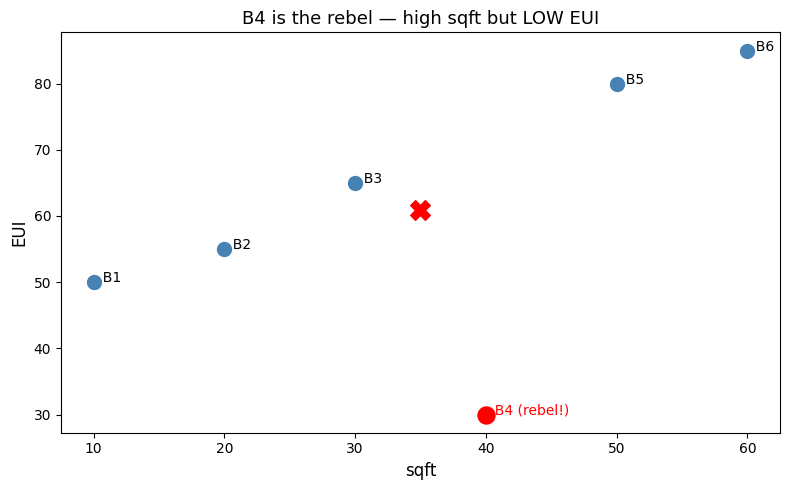

Building 4 has sqft=40 (above average) but EUI=30 (below average).
It goes AGAINST the upward trend.
The best slope should be LOWER because of this rebel point.


In [3]:
# Same buildings, but B4 now goes AGAINST the trend
sqft_v2 = np.array([10, 20, 30, 40, 50, 60], dtype=float)
eui_v2  = np.array([50, 55, 65, 30, 80, 85], dtype=float)  # B4 changed: 70 -> 30

avg_sqft_v2 = sqft_v2.mean()
avg_eui_v2 = eui_v2.mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sqft_v2[:3], eui_v2[:3], color='steelblue', s=100, zorder=5)
ax.scatter(sqft_v2[3], eui_v2[3], color='red', s=150, zorder=5)  # the rebel
ax.scatter(sqft_v2[4:], eui_v2[4:], color='steelblue', s=100, zorder=5)
ax.scatter(avg_sqft_v2, avg_eui_v2, color='red', s=200, marker='X', zorder=5)

for i in range(len(sqft_v2)):
    label = f'  B{i+1}' if i != 3 else f'  B4 (rebel!)'
    ax.annotate(label, xy=(sqft_v2[i], eui_v2[i]), fontsize=10,
                color='red' if i == 3 else 'black')

ax.set_xlabel('sqft', fontsize=12)
ax.set_ylabel('EUI', fontsize=12)
ax.set_title('B4 is the rebel — high sqft but LOW EUI', fontsize=13)
plt.tight_layout()
plt.show()

print('Building 4 has sqft=40 (above average) but EUI=30 (below average).')
print('It goes AGAINST the upward trend.')
print('The best slope should be LOWER because of this rebel point.')

## What does the rebel's rise x run look like?

In [4]:
runs_v2  = sqft_v2 - avg_sqft_v2
rises_v2 = eui_v2 - avg_eui_v2

print('Each building\'s run, rise, and their product:')
print()
print('Building |  run   |  rise  | run x rise | direction')
print('-' * 65)
for i in range(len(sqft_v2)):
    product = runs_v2[i] * rises_v2[i]
    if runs_v2[i] < 0 and rises_v2[i] < 0:
        direction = 'both below avg -> AGREES'
    elif runs_v2[i] > 0 and rises_v2[i] > 0:
        direction = 'both above avg -> AGREES'
    elif runs_v2[i] > 0 and rises_v2[i] < 0:
        direction = 'right but DOWN -> DISAGREES'
    else:
        direction = 'left but UP -> DISAGREES'
    
    marker = ' <-- REBEL' if i == 3 else ''
    print(f'   B{i+1}    | {runs_v2[i]:+6.1f} | {rises_v2[i]:+6.1f} | {product:+10.2f} | {direction}{marker}')

print()
print('B4\'s product is NEGATIVE because it disagrees with the trend.')
print('When we add all products, B4\'s negative pulls the total DOWN.')
print('That makes the slope LOWER. Exactly what we want!')

Each building's run, rise, and their product:

Building |  run   |  rise  | run x rise | direction
-----------------------------------------------------------------
   B1    |  -25.0 |  -10.8 |    +270.83 | both below avg -> AGREES
   B2    |  -15.0 |   -5.8 |     +87.50 | both below avg -> AGREES
   B3    |   -5.0 |   +4.2 |     -20.83 | left but UP -> DISAGREES
   B4    |   +5.0 |  -30.8 |    -154.17 | right but DOWN -> DISAGREES <-- REBEL
   B5    |  +15.0 |  +19.2 |    +287.50 | both above avg -> AGREES
   B6    |  +25.0 |  +24.2 |    +604.17 | both above avg -> AGREES

B4's product is NEGATIVE because it disagrees with the trend.
When we add all products, B4's negative pulls the total DOWN.
That makes the slope LOWER. Exactly what we want!


## Now compare: our method vs squaring both

In [5]:
# OUR METHOD: keeps direction
products_v2 = runs_v2 * rises_v2
our_top = products_v2.sum()
our_bottom = (runs_v2 ** 2).sum()
our_slope_v2 = our_top / our_bottom

print('OUR METHOD: run x rise / run²')
print()
print('Products:', [f'{p:+.1f}' for p in products_v2])
print(f'Sum of products (top):     {our_top:.1f}  <-- B4\'s negative pulled this down')
print(f'Sum of run² (bottom):      {our_bottom:.1f}')
print(f'Slope:                     {our_slope_v2:.4f}')

OUR METHOD: run x rise / run²

Products: ['+270.8', '+87.5', '-20.8', '-154.2', '+287.5', '+604.2']
Sum of products (top):     1075.0  <-- B4's negative pulled this down
Sum of run² (bottom):      1750.0
Slope:                     0.6143


In [6]:
# YOUR IDEA: square both — direction is lost
rises_squared = rises_v2 ** 2
runs_squared = runs_v2 ** 2

your_top = rises_squared.sum()
your_bottom = runs_squared.sum()
your_slope_v2 = np.sqrt(your_top / your_bottom)

print('YOUR IDEA: sqrt(rise² / run²)')
print()
print('Rise² values:', [f'{r:.1f}' for r in rises_squared])
print(f'Sum of rise² (top):        {your_top:.1f}  <-- B4\'s value is POSITIVE (squaring killed the sign!)')
print(f'Sum of run² (bottom):      {your_bottom:.1f}')
print(f'Slope:                     {your_slope_v2:.4f}')

YOUR IDEA: sqrt(rise² / run²)

Rise² values: ['117.4', '34.0', '17.4', '950.7', '367.4', '584.0']
Sum of rise² (top):        2070.8  <-- B4's value is POSITIVE (squaring killed the sign!)
Sum of run² (bottom):      1750.0
Slope:                     1.0878


In [7]:
# Side by side comparison
print('COMPARISON')
print('=' * 50)
print(f'Our method:  slope = {our_slope_v2:.4f}')
print(f'Your idea:   slope = {your_slope_v2:.4f}')
print()
print(f'Our method gives a LOWER slope because B4 pulled it down.')
print(f'Your idea gives a HIGHER slope because squaring hid B4\'s disagreement.')
print()
print('Which one is right? Let\'s draw both lines and see.')

COMPARISON
Our method:  slope = 0.6143
Your idea:   slope = 1.0878

Our method gives a LOWER slope because B4 pulled it down.
Your idea gives a HIGHER slope because squaring hid B4's disagreement.

Which one is right? Let's draw both lines and see.


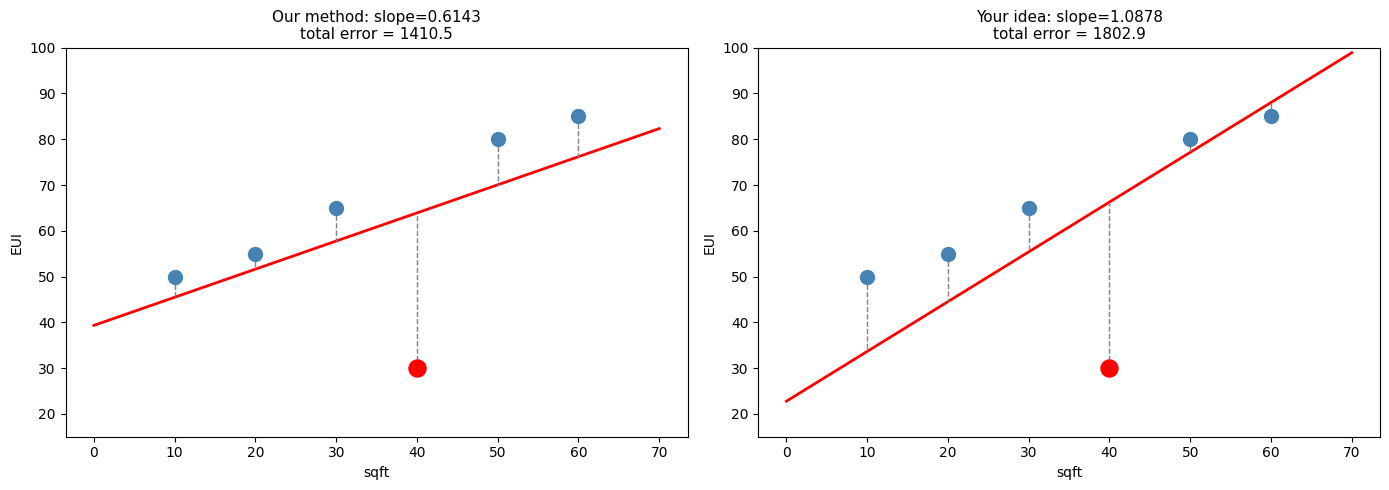

Look at the total error numbers.
Our method has LOWER total error — the line fits the data better.
Your idea's line is too steep — it ignored that B4 pulls the trend down.


In [8]:
# Draw both lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_line = np.linspace(0, 70, 100)

for ax, slope, title in [
    (axes[0], our_slope_v2, f'Our method: slope={our_slope_v2:.4f}'),
    (axes[1], your_slope_v2, f'Your idea: slope={your_slope_v2:.4f}'),
]:
    b = avg_eui_v2 - slope * avg_sqft_v2
    predictions = slope * sqft_v2 + b
    total_error = ((eui_v2 - predictions) ** 2).sum()
    
    ax.scatter(sqft_v2[:3], eui_v2[:3], color='steelblue', s=100, zorder=5)
    ax.scatter(sqft_v2[3], eui_v2[3], color='red', s=150, zorder=5)
    ax.scatter(sqft_v2[4:], eui_v2[4:], color='steelblue', s=100, zorder=5)
    ax.plot(x_line, slope * x_line + b, color='red', linewidth=2)
    
    for i in range(len(sqft_v2)):
        ax.plot([sqft_v2[i], sqft_v2[i]], [eui_v2[i], predictions[i]], 'gray', linestyle='--', linewidth=1)
    
    ax.set_title(f'{title}\ntotal error = {total_error:.1f}', fontsize=11)
    ax.set_xlabel('sqft')
    ax.set_ylabel('EUI')
    ax.set_ylim(15, 100)

plt.tight_layout()
plt.show()

print('Look at the total error numbers.')
print('Our method has LOWER total error — the line fits the data better.')
print('Your idea\'s line is too steep — it ignored that B4 pulls the trend down.')

## One more test: what if the trend goes DOWNWARD?

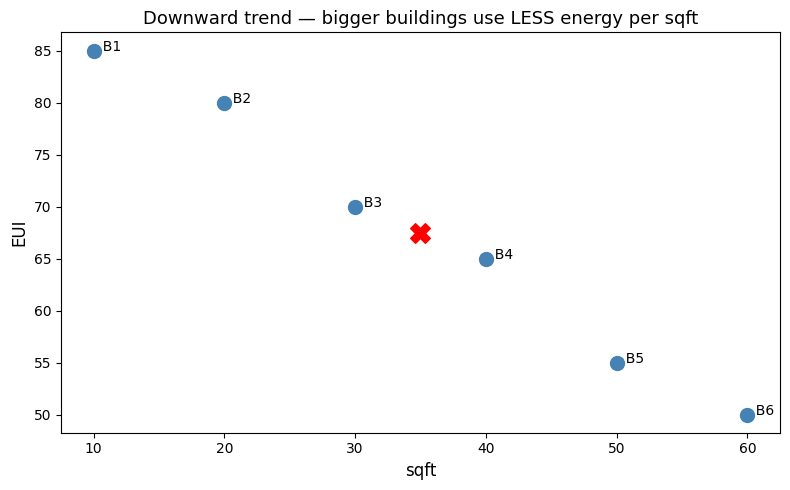

The slope should be NEGATIVE — the line goes downhill.


In [9]:
# Downward trend: bigger buildings use LESS energy per sqft
sqft_v3 = np.array([10, 20, 30, 40, 50, 60], dtype=float)
eui_v3  = np.array([85, 80, 70, 65, 55, 50], dtype=float)  # reversed!

avg_sqft_v3 = sqft_v3.mean()
avg_eui_v3 = eui_v3.mean()
runs_v3  = sqft_v3 - avg_sqft_v3
rises_v3 = eui_v3 - avg_eui_v3

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sqft_v3, eui_v3, color='steelblue', s=100, zorder=5)
ax.scatter(avg_sqft_v3, avg_eui_v3, color='red', s=200, marker='X', zorder=5)
for i in range(len(sqft_v3)):
    ax.annotate(f'  B{i+1}', xy=(sqft_v3[i], eui_v3[i]), fontsize=10)
ax.set_xlabel('sqft', fontsize=12)
ax.set_ylabel('EUI', fontsize=12)
ax.set_title('Downward trend — bigger buildings use LESS energy per sqft', fontsize=13)
plt.tight_layout()
plt.show()

print('The slope should be NEGATIVE — the line goes downhill.')

In [10]:
# Compare methods on downward data
our_slope_v3 = (runs_v3 * rises_v3).sum() / (runs_v3 ** 2).sum()
your_slope_v3 = np.sqrt((rises_v3 ** 2).sum() / (runs_v3 ** 2).sum())

print('The slope SHOULD be negative (downhill).')
print()
print(f'Our method:  {our_slope_v3:.4f}  <-- NEGATIVE (correct!)')
print(f'Your idea:   {your_slope_v3:.4f}  <-- POSITIVE (wrong!)')
print()
print('Squaring both rise and run makes everything positive.')
print('It can NEVER give a negative slope.')
print('It literally cannot tell the difference between uphill and downhill.')

The slope SHOULD be negative (downhill).

Our method:  -0.7286  <-- NEGATIVE (correct!)
Your idea:   0.7319  <-- POSITIVE (wrong!)

Squaring both rise and run makes everything positive.
It can NEVER give a negative slope.
It literally cannot tell the difference between uphill and downhill.


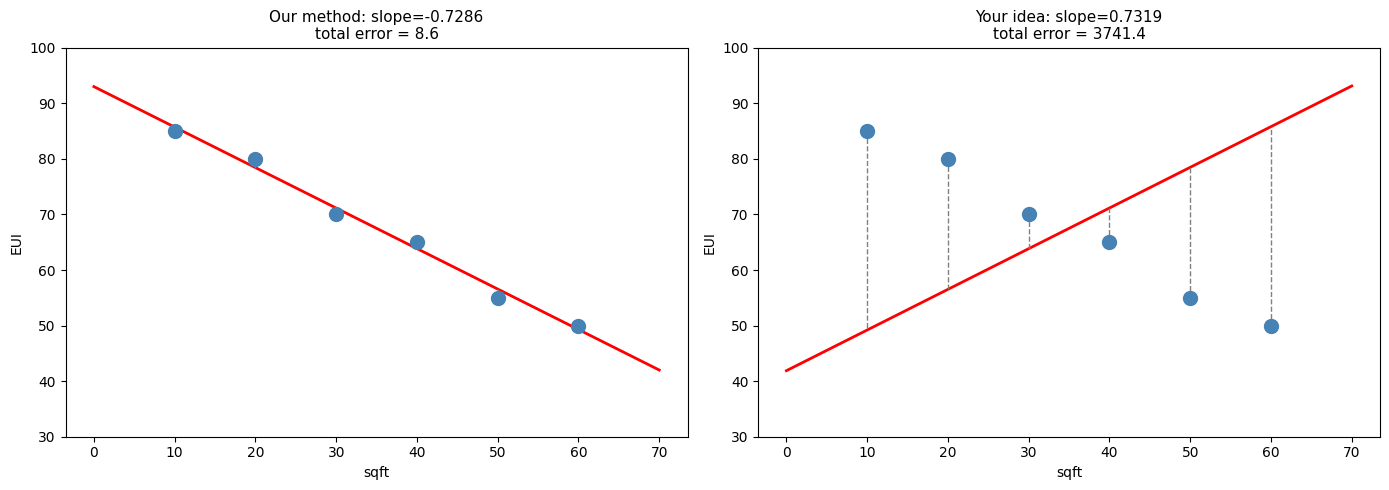

Our method fits perfectly — the line goes downhill with the data.
Your idea goes UPHILL on downhill data — completely wrong.


In [11]:
# Draw both lines on the downward data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_line = np.linspace(0, 70, 100)

for ax, slope, title in [
    (axes[0], our_slope_v3, f'Our method: slope={our_slope_v3:.4f}'),
    (axes[1], your_slope_v3, f'Your idea: slope={your_slope_v3:.4f}'),
]:
    b = avg_eui_v3 - slope * avg_sqft_v3
    predictions = slope * sqft_v3 + b
    total_error = ((eui_v3 - predictions) ** 2).sum()
    
    ax.scatter(sqft_v3, eui_v3, color='steelblue', s=100, zorder=5)
    ax.plot(x_line, slope * x_line + b, color='red', linewidth=2)
    
    for i in range(len(sqft_v3)):
        ax.plot([sqft_v3[i], sqft_v3[i]], [eui_v3[i], predictions[i]], 'gray', linestyle='--', linewidth=1)
    
    ax.set_title(f'{title}\ntotal error = {total_error:.1f}', fontsize=11)
    ax.set_xlabel('sqft')
    ax.set_ylabel('EUI')
    ax.set_ylim(30, 100)

plt.tight_layout()
plt.show()

print('Our method fits perfectly — the line goes downhill with the data.')
print('Your idea goes UPHILL on downhill data — completely wrong.')

## Summary

**Why multiply rise x run instead of squaring both?**

1. **Multiplication keeps the sign.** A point that goes against the trend produces a negative product, which pulls the slope in the right direction.

2. **Squaring destroys the sign.** (-17.5)² = 306.25 and (+17.5)² = 306.25 — you can't tell them apart. A point going against the trend looks the same as one going with it.

3. **Squaring can never give a negative slope.** Positive / positive = positive. Always. It literally can't represent a downhill trend.

The bottom of the fraction (run²) only needs to measure spread — direction doesn't matter there. But the top MUST preserve direction, so we multiply instead of squaring.